In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load Dataset


In [3]:
dataset_file_name = '/content/drive/MyDrive/Machine Learning/K-Means/covid_data.csv'
df = pd.read_csv(dataset_file_name)
df.head()

,State,Confirmed,Recovered,Deaths
0,Maharashtra,41642,11726,1454
1,Tamil Nadu,13967,6282,95
2,Gujarat,12910,5488,773
3,Delhi,11659,5567,194
4,Rajasthan,6227,3485,151


# Pre-processing

In [4]:
df.columns

Index(['State', 'Confirmed', 'Recovered', 'Deaths'], dtype='object')

In [5]:
df['% Deaths'] = df['Deaths'] / df['Confirmed']
df['% Recovered'] = df['Recovered'] / df['Confirmed']

In [6]:
columns_to_use = ['% Deaths', '% Recovered']
df_selected = df.loc[:, columns_to_use]
df_selected.head()

,% Deaths,% Recovered
0,0.034917,0.281591
1,0.006802,0.449774
2,0.059876,0.425097
3,0.016640,0.477485
4,0.024249,0.559660


In [7]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
# Kiểm tra và thay thế các giá trị vô hạn bằng NaN
df_selected.replace([np.inf, -np.inf], np.nan, inplace=True)

# Kiểm tra và xử lý giá trị thiếu
missing_values = df_selected.isnull().sum()
if missing_values.sum() != 0:
    imputer = SimpleImputer(strategy='constant', fill_value=0)
    df_selected = imputer.fit_transform(df_selected)

# scaler = StandardScaler()
# df_selected = scaler.fit_transform(df_selected)

# Clustering

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
def evaluate_clustering(X, labels, model):
  """
    Function to caculate silhouette_score, calinski_harabasz_score, davies_bouldin_score, wcss

    Params:
    X: input data use for clustering
    labels: the cluster labels assigned to each data point
    model: clustering model

    Return: silhouette_score, calinski_harabasz_score, davies_bouldin_score, wcss
  """
  silhouette = silhouette_score(X, labels)
  calinski_harabasz = calinski_harabasz_score(X, labels)
  davies_bouldin = davies_bouldin_score(X, labels)

  wcss = model.inertia_
  return silhouette, calinski_harabasz, davies_bouldin, wcss

def cluster_and_evaluate(X, n_clusters_list):
  """
    Function to perform cluster and evaluate

    Params:
    X: input data use for clustering
    n_clusters_list: list of number of clusters.

    Return: dictionary of results include 4 metrics per number of clusters.
  """
  results = {n: {} for n in n_clusters_list}
  for n in tqdm(n_clusters_list, desc='Processing'):
    kmeans = KMeans(n_clusters=n, random_state=0).fit(X)
    labels = kmeans.labels_
    results[n] = evaluate_clustering(X, labels, kmeans)
  return results

In [16]:
cluster_results = {}

In [17]:
n_clusters_list = range(2, 10, 1)
n_cluster_to_run = [n for n in n_clusters_list if n not in cluster_results]
if n_cluster_to_run:
  new_cluster_results = cluster_and_evaluate(df_selected, n_cluster_to_run)
  cluster_results.update(new_cluster_results)

Processing: 100%|██████████| 8/8 [00:00<00:00, 92.65it/s]


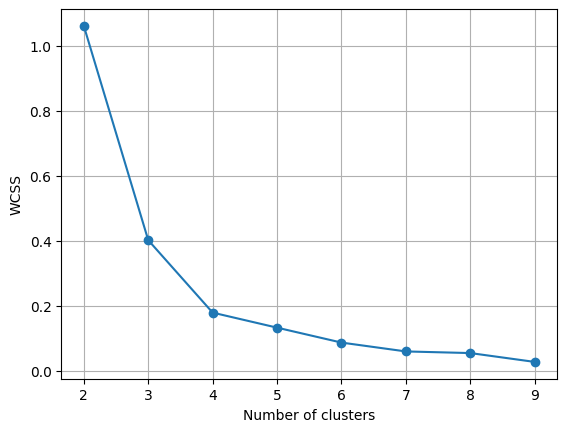

In [54]:
def plot_elbow_method(results):
  n_list = sorted(results.keys())
  wcss_list = [results[n][3] for n in n_list]
  plt.plot(n_list, wcss_list, marker='o')
  plt.xlabel('Number of clusters')
  plt.ylabel('WCSS')
  plt.xticks(n_clusters_list)
  plt.grid()
  plt.show()
plot_elbow_method(cluster_results)

In [19]:
optimal_n_cluster = 4

model = KMeans(n_clusters=optimal_n_cluster, random_state=42).fit(df_selected)
labels = model.predict(df_selected)

In [40]:
df['Zone'] = labels + 1
df.head()

,State,Confirmed,Recovered,Deaths,% Deaths,% Recovered,Zone
0,Maharashtra,41642,11726,1454,0.034917,0.281591,1
1,Tamil Nadu,13967,6282,95,0.006802,0.449774,1
2,Gujarat,12910,5488,773,0.059876,0.425097,1
3,Delhi,11659,5567,194,0.016640,0.477485,1
4,Rajasthan,6227,3485,151,0.024249,0.559660,4


In [41]:
import folium
state_coords = {
    "Andhra Pradesh": (15.9129 , 79.7399) ,
    "Arunachal Pradesh": (28.2180 , 94.7278) ,
    "Assam": (26.2006 , 92.9376) ,
    "Bihar": (25.0961 , 85.3131) ,
    "Chhattisgarh": (21.2787 , 81.8661) ,
    "Goa": (15.2993 , 74.1240) ,
    "Gujarat": (22.2587 , 71.1924) ,
    "Haryana": (29.0588 , 76.0856) ,
    "Himachal Pradesh": (31.1048 , 77.1734) ,
    "Jharkhand": (23.6102 , 85.2799) ,
    "Karnataka": (15.3173 , 75.7139) ,
    "Kerala": (10.8505 , 76.2711) ,
    "Madhya Pradesh": (22.9734 , 78.6569) ,
    "Maharashtra": (19.7515 , 75.7139) ,
    "Manipur": (24.6637 , 93.9063) ,
    "Meghalaya": (25.4670 , 91.3662) ,
    "Mizoram": (23.1645 , 92.9376) ,
    "Nagaland": (26.1584 , 94.5624) ,
    "Odisha": (20.9517 , 85.0985) ,
    "Punjab": (31.1471 , 75.3412) ,
    "Rajasthan": (27.0238 , 74.2179) ,
    "Sikkim": (27.5330 , 88.5122) ,
    "Tamil Nadu": (11.1271 , 78.6569) ,
    "Telangana": (18.1124 , 79.0193) ,
    "Tripura": (23.9408 , 91.9882) ,
    "Uttar Pradesh": (26.8467 , 80.9462) ,
    "Uttarakhand": (30.0668 , 79.0193) ,
    "West Bengal": (22.9868 , 87.8550) ,
    "Andaman and Nicobar Islands": (11.7401 , 92.6586) ,
    "Chandigarh": (30.7333 , 76.7794) ,
    "Dadra and Nagar Haveli and Daman and Diu": (20.2270 , 73.0169) ,
    "Delhi": (28.7041 , 77.1025) ,
    "Jammu and Kashmir": (33.7782 , 76.5762) ,
    "Ladakh": (34.1526 , 77.5806) ,
    "Lakshadweep": (10.5593 , 72.6358) ,
    "Puducherry": (11.9416 , 79.8083) ,
    "Orissa": (20.9517 , 85.0985) # Added Orissa for consistency
}

In [51]:
map_india = folium.Map (location =[20.5937 , 78.9629] , zoom_start =5)
for index, row in df.iterrows():
  state = row['State']
  zone = row['Zone']
  if state in state_coords:
    lat, lon = state_coords[state]
    if zone == 1:
      color = 'green'
    elif zone == 2:
      color = 'yellow'
    elif zone == 3:
      color = 'orange'
    elif zone == 4:
      color = 'red'
    folium.Marker(
        location = [lat, lon],
        popup = f'State: {state} - Zone: {zone}',
        icon = folium.Icon(color=color)
    ).add_to(map_india)
map_india

<ipython-input-51-b5c050526203>:18: UserWarning: color argument of Icon should be one of: {'darkpurple', 'white', 'darkred', 'darkblue', 'beige', 'pink', 'lightgray', 'orange', 'lightblue', 'red', 'green', 'black', 'lightgreen', 'cadetblue', 'darkgreen', 'gray', 'lightred', 'blue', 'purple'}.
  icon = folium.Icon(color=color)
